In [142]:
import io, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import gcamreader
from lxml import etree
warnings.filterwarnings('ignore')

SPEIZER_DIR = '../scenarios/speizer2023/10028915/steel_decarb_runs_output'
DB_DIR      = '../output'
DB_NAME     = 'speizer_basexdb'

SCEN_ORDER = ['Reference_1', '1p5C_12', '1p5C_13', '1p5C_delay_14']
SCENARIO_MAP = {
    'Reference_1':   'Speizer_Reference_1',
    '1p5C_12':       'Speizer_1p5C',
    '1p5C_13':       'Speizer_1p5C_noCCS',
    '1p5C_delay_14': 'Speizer_1p5C_delay',
}
LABELS = {
    'Reference_1':   'Reference',
    '1p5C_12':       '1.5\u00b0C orderly',
    '1p5C_13':       '1.5\u00b0C no-CCS',
    '1p5C_delay_14': '1.5\u00b0C delay',
}
COLORS = {
    'Reference_1':   '#888888',
    '1p5C_12':       '#2196F3',
    '1p5C_13':       '#E53935',
    '1p5C_delay_14': '#FB8C00',
}
MTC_TO_MTCO2 = 44 / 12
REV_MAP = {v: k for k, v in SCENARIO_MAP.items()}

In [143]:
# ── Speizer CSV loader ────────────────────────────────────────────────────────
def load_speizer(fname, id_cols):
    chunks, header, buf = [], None, []
    for line in open(f'{SPEIZER_DIR}/{fname}').readlines()[1:]:
        if line.startswith('scenario,'):
            if header and buf:
                try: chunks.append(pd.read_csv(io.StringIO(header + ''.join(buf))))
                except: pass
            header, buf = line, []
        elif header and line.strip():
            buf.append(line)
    if header and buf:
        try: chunks.append(pd.read_csv(io.StringIO(header + ''.join(buf))))
        except: pass
    df = pd.concat(chunks, ignore_index=True)
    df['scen'] = df['scenario'].str.split(',').str[0]
    df = df[df['scen'].isin(SCENARIO_MAP)]
    year_cols = [c for c in df.columns if str(c).isdigit()]
    return (
        df[id_cols + ['scen'] + year_cols]
        .melt(id_vars=id_cols + ['scen'], var_name='year', value_name='value')
        .assign(year=lambda d: d['year'].astype(int))
        .dropna(subset=['value'])
        .query('year >= 2020')
    )

# Load all Speizer data
sp_co2 = (
    load_speizer('queryoutall_CO2_emissions_sector_nobio_v2.csv', ['region', 'sector'])
    .query('sector == "iron and steel"')
    .groupby(['scen', 'year'], as_index=False)['value'].sum()
    .assign(MtCO2=lambda d: d['value'] * MTC_TO_MTCO2)
)

sp_prod = load_speizer('queryoutall_ironsteel_production_tech.csv',
                        ['region', 'sector', 'subsector', 'output', 'technology'])

sp_energy = (
    load_speizer('queryoutall_ironsteel_input_tech.csv', ['region', 'sector', 'input'])
    .groupby(['scen', 'year'], as_index=False)['value'].sum()
)

sp_seq = (
    load_speizer('queryoutall_CO2_squestration_tech.csv',
                 ['region', 'sector', 'technology', 'subsector'])
    .query('sector == "iron and steel"')
    .groupby(['scen', 'year'], as_index=False)['value'].sum()
    .assign(MtCO2=lambda d: d['value'] * MTC_TO_MTCO2)
)

# ── DB connection ─────────────────────────────────────────────────────────────
db_co2 = db_prod = db_energy = db_seq = pd.DataFrame()
conn, completed = None, []
try:
    conn = gcamreader.querymi.LocalDBConn(DB_DIR, DB_NAME)
    avail = conn.listScenariosInDB()['name'].tolist()
    completed = [s for s in SCENARIO_MAP.values() if any(s in a for a in avail)]
    completed_keys = [k for k, v in SCENARIO_MAP.items() if v in completed]
    tree = etree.parse('../output/queries/Main_queries.xml')

    def qry(title, tag='supplyDemandQuery'):
        for t in [tag, 'emissionsQueryBuilder', 'supplyDemandQuery']:
            for el in tree.getroot().iter(t):
                if el.get('title') == title:
                    return conn.runQuery(gcamreader.querymi.Query(el), scenarios=completed)
        return pd.DataFrame()

    def normalise(df, value_col='value'):
        if df.empty: return df
        df = df.copy()
        df['scen'] = df['scenario'].str.split(',').str[0].map(REV_MAP)
        df['year']  = df['Year']
        return df.dropna(subset=['scen']).query('year >= 2020')

    raw = qry('CO2 emissions by sector (excluding resource production)', 'emissionsQueryBuilder')
    if not raw.empty:
        db_co2 = (
            normalise(raw)
            .query('sector == "iron and steel"')
            .groupby(['scen', 'year'], as_index=False)['value'].sum()
            .assign(MtCO2=lambda d: d['value'] * MTC_TO_MTCO2)
        )

    raw = qry('iron and steel production by tech')
    if not raw.empty:
        db_prod = normalise(raw)

    raw = qry('iron and steel inputs by tech (energy and feedstocks)')
    if not raw.empty:
        db_energy = (
            normalise(raw)
            .groupby(['scen', 'year'], as_index=False)['value'].sum()
        )

    raw = qry('CO2 sequestration by tech', 'emissionsQueryBuilder')
    if not raw.empty:
        db_seq = (
            normalise(raw)
            .query('sector == "iron and steel"')
            .groupby(['scen', 'year'], as_index=False)['value'].sum()
            .assign(MtCO2=lambda d: d['value'] * MTC_TO_MTCO2)
        )

    print('Completed scenarios:', completed_keys)
except Exception as e:
    print('DB error:', e)
    completed_keys = []

# ── Plot helpers ──────────────────────────────────────────────────────────────
def make_legend(ax):
    handles = []
    for k in SCEN_ORDER:
        if k not in completed_keys:
            continue
        c = COLORS[k]
        label = LABELS[k]
        handles.append(mlines.Line2D([], [], color=c, lw=2, ls='-',  label=f'{label}_Speizer'))
        handles.append(mlines.Line2D([], [], color=c, lw=2, ls='--', label=f'{label}_GCAM8.2'))
    ax.legend(handles=handles, fontsize=8, loc='upper left', framealpha=0.7)

def plot_scenario_lines(ax, sp_df, db_df, key_col='MtCO2'):
    for k in SCEN_ORDER:
        if k not in completed_keys:
            continue
        c = COLORS[k]
        sub = sp_df[sp_df['scen'] == k].sort_values('year')
        if not sub.empty:
            ax.plot(sub['year'], sub[key_col], color=c, lw=2, ls='-')
        if not db_df.empty:
            sub2 = db_df[db_df['scen'] == k].sort_values('year')
            if not sub2.empty:
                ax.plot(sub2['year'], sub2[key_col], color=c, lw=2, ls='--')

def finish_ax(ax, ylabel, title):
    ax.set_xlim(2020, 2100)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.tick_params(labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    make_legend(ax)
    plt.tight_layout()
    plt.show()

Database scenarios: Speizer_Reference_1
Completed scenarios: ['Reference_1']


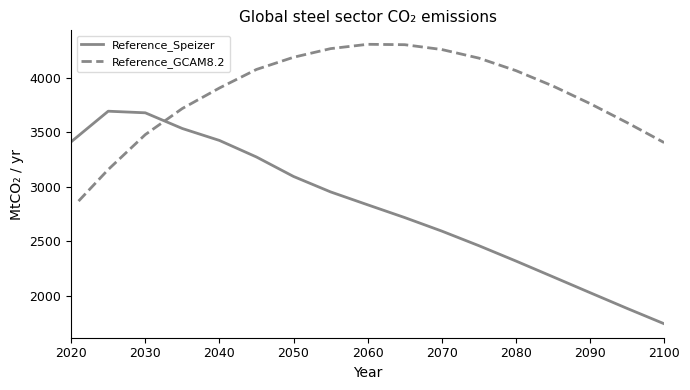

In [144]:
# Cell 1 — Steel sector CO2 emissions
fig, ax = plt.subplots(figsize=(7, 4))
plot_scenario_lines(ax, sp_co2, db_co2, key_col='MtCO2')
finish_ax(ax, 'MtCO\u2082 / yr', 'Global steel sector CO\u2082 emissions')

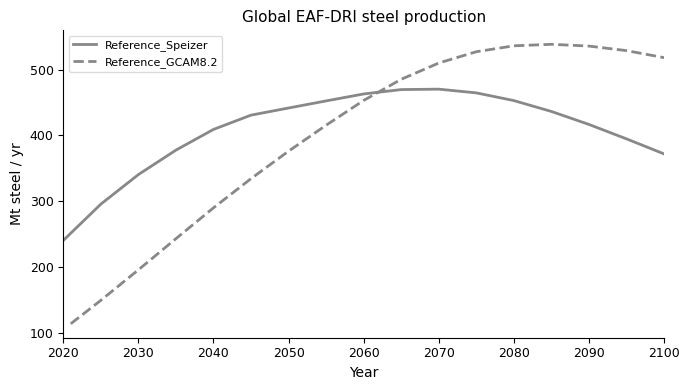

In [145]:
# Cell 2 — EAF-DRI production (total, all technologies in EAF with DRI subsector)
sp_eaf = (
    sp_prod.query('subsector == "EAF with DRI"')
    .groupby(['scen', 'year'], as_index=False)['value'].sum()
    .rename(columns={'value': 'Mt'})
)
db_eaf = pd.DataFrame()
if not db_prod.empty:
    db_eaf = (
        db_prod.query('subsector == "EAF with DRI"')
        .groupby(['scen', 'year'], as_index=False)['value'].sum()
        .rename(columns={'value': 'Mt'})
    )
fig, ax = plt.subplots(figsize=(7, 4))
plot_scenario_lines(ax, sp_eaf, db_eaf, key_col='Mt')
finish_ax(ax, 'Mt steel / yr', 'Global EAF-DRI steel production')

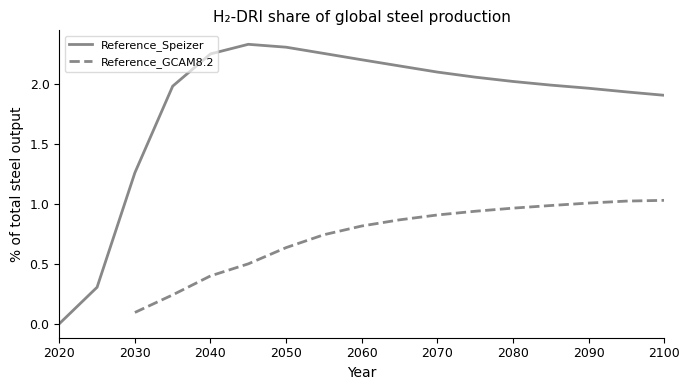

In [146]:
# Cell 3 — H2-DRI share of total steel production (%)
sp_h2 = (
    sp_prod.query('technology == "Hydrogen-based DRI"')
    .groupby(['scen', 'year'], as_index=False)['value'].sum()
    .rename(columns={'value': 'h2'})
)
sp_tot = (
    sp_prod.groupby(['scen', 'year'], as_index=False)['value'].sum()
    .rename(columns={'value': 'total'})
)
sp_h2share = (
    sp_h2.merge(sp_tot, on=['scen', 'year'])
    .assign(pct=lambda d: d['h2'] / d['total'] * 100)
)

db_h2share = pd.DataFrame()
if not db_prod.empty:
    db_h2 = (
        db_prod.query('technology == "Hydrogen-based DRI"')
        .groupby(['scen', 'year'], as_index=False)['value'].sum()
        .rename(columns={'value': 'h2'})
    )
    db_tot = (
        db_prod.groupby(['scen', 'year'], as_index=False)['value'].sum()
        .rename(columns={'value': 'total'})
    )
    db_h2share = (
        db_h2.merge(db_tot, on=['scen', 'year'])
        .assign(pct=lambda d: d['h2'] / d['total'] * 100)
    )

fig, ax = plt.subplots(figsize=(7, 4))
plot_scenario_lines(ax, sp_h2share, db_h2share, key_col='pct')
finish_ax(ax, '% of total steel output', 'H\u2082-DRI share of global steel production')

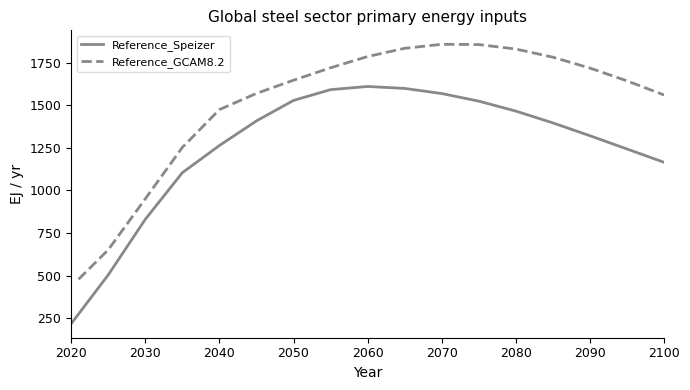

In [147]:
# Cell 4 — Steel sector primary energy inputs (EJ/yr)
fig, ax = plt.subplots(figsize=(7, 4))
plot_scenario_lines(ax, sp_energy.rename(columns={'value': 'EJ'}),
                    db_energy.rename(columns={'value': 'EJ'}) if not db_energy.empty else pd.DataFrame(),
                    key_col='EJ')
finish_ax(ax, 'EJ / yr', 'Global steel sector primary energy inputs')

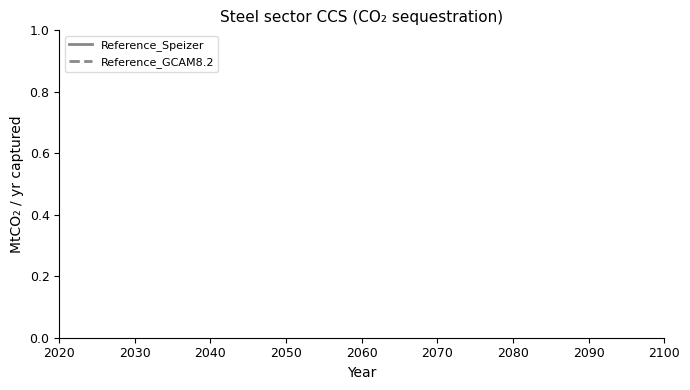

In [148]:
# Cell 5 — CCS captured in steel sector (MtCO2/yr)
fig, ax = plt.subplots(figsize=(7, 4))
plot_scenario_lines(ax, sp_seq, db_seq, key_col='MtCO2')
finish_ax(ax, 'MtCO\u2082 / yr captured', 'Steel sector CCS (CO\u2082 sequestration)')

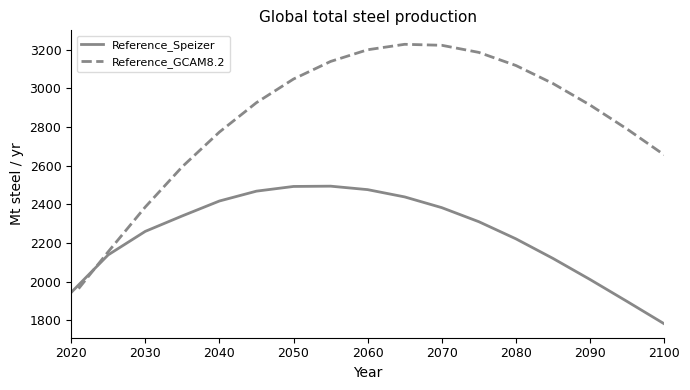

In [149]:
# Cell 6 — Global total steel production (Mt/yr)
sp_total = (
    sp_prod.groupby(['scen', 'year'], as_index=False)['value'].sum()
    .rename(columns={'value': 'Mt'})
)
db_total = pd.DataFrame()
if not db_prod.empty:
    db_total = (
        db_prod.groupby(['scen', 'year'], as_index=False)['value'].sum()
        .rename(columns={'value': 'Mt'})
    )
fig, ax = plt.subplots(figsize=(7, 4))
plot_scenario_lines(ax, sp_total, db_total, key_col='Mt')
finish_ax(ax, 'Mt steel / yr', 'Global total steel production')